In [ ]:
import torch
import soundfile as sf
from audiomentations import LowPassFilter, HighPassFilter, PitchShift, Gain, BandStopFilter, AddBackgroundNoise, LoudnessNormalization, ApplyImpulseResponse, SevenBandParametricEQ 
from IPython.display import display, Audio
import matplotlib.pyplot as plt
import warnings
import torchaudio

import os
print(f"Current working directory: {os.getcwd()}")

#### Audio File Info

In [ ]:
sample_rates = set()
channels = set()
durations = []
format = set()
subtype = set()

for filename in os.listdir("../audio_files"):
    file_path = os.path.join("../audio_files", filename)
    info = sf.info(file_path)

    sample_rates.add(info.samplerate) # Has units of Hz
    channels.add(info.channels)
    durations.append(info.duration)
    format.add(info.format)
    if (info.subtype == "FLOAT"): subtype.add("32-bit float")
    else: subtype.add(info.subtype)

print(f"Sample Rates: {sample_rates}")
print(f"Channels: {channels}")
print(f"Durations: Min = {min(durations)}, Max = {max(durations)}, Mean = {sum(durations)/len(durations)}")
print(f"Formats: {format}")
print(f"Subtypes: {subtype}")

Sample Rates: {8000}
Channels: {1}
Durations: Min = 1.516125, Max = 7.208, Mean = 3.324087962962963
Formats: {'WAVEX'}
Subtypes: {'32-bit float'}


#### Plotting Functions

In [4]:
def plot_waveform(waveform, sr, title, ax=None):
    # waveform is a pytorch tensor of shape (num of channels, num of frames)
    waveform = waveform.numpy()
    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sr
    ax.plot(time_axis, waveform[0], linewidth=1, color="#2488B2")
    ax.grid(True)
    ax.set_xlim(0, time_axis[-1])
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    return plt

def plot_spectrogram(waveform, sr, title, min_db, max_db, ax=None):
    # waveform is a pytorch tensor of shape (num of channels, num of frames)
    spectrogram_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )
    spectrogram = spectrogram_transform(waveform)
    spec_db = torchaudio.transforms.AmplitudeToDB()(spectrogram) # (channels, n_mels, num_frames)
    ax.set_title(title)
    ax.set_xlabel("Time Frames")
    ax.set_ylabel("Mel Frequency Bands (Hz)")
    # Audio is mono so we take the first channel using spec_db[0].numpy()
    # This gives us a 2D array of shape (n_mels, num_frames) that we can plot
    pos = ax.imshow(
        spec_db[0].numpy(), 
        origin="lower", 
        aspect="auto", 
        cmap='magma',
        vmin = min_db, 
        vmax = max_db)
    plt.colorbar(pos, ax=ax, format="%+2.0f dB")
    return plt

def plot_all(audio, taudio, sr, og_title_prefix, augmented_title_prefix):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    plot_waveform(audio, sr, f"{og_title_prefix} Waveform", ax=axs[0,0])
    plot_waveform(taudio, sr, f"{augmented_title_prefix} Waveform", ax=axs[0,1])
    
    # Need to first calculate the scale by generating both spectorgrams
    spectrogram_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )
    spec = spectrogram_transform(audio)
    spec_db = torchaudio.transforms.AmplitudeToDB()(spec)
    tspec = spectrogram_transform(taudio)
    tspec_db = torchaudio.transforms.AmplitudeToDB()(tspec)
    min_db = min(spec_db.min().item(), tspec_db.min().item())
    max_db = max(spec_db.max().item(), tspec_db.max().item())
    
    plot_spectrogram(audio, sr, f"{og_title_prefix} Spectrogram", ax=axs[1,0],
                     min_db=min_db, max_db=max_db)
    plot_spectrogram(taudio, sr, f"{augmented_title_prefix} Spectrogram", ax=axs[1,1],
                     min_db=min_db, max_db=max_db)
    plt.tight_layout()
    plt.show()

#### Frequency Filters


##### Low-Pass Filter
This removes all frequencies above the cut-off frequency.
The cut-off frequency is randomly chosen between the min_cutoff_freq and max_cutoff_freq parameters

Original


Low pass filter


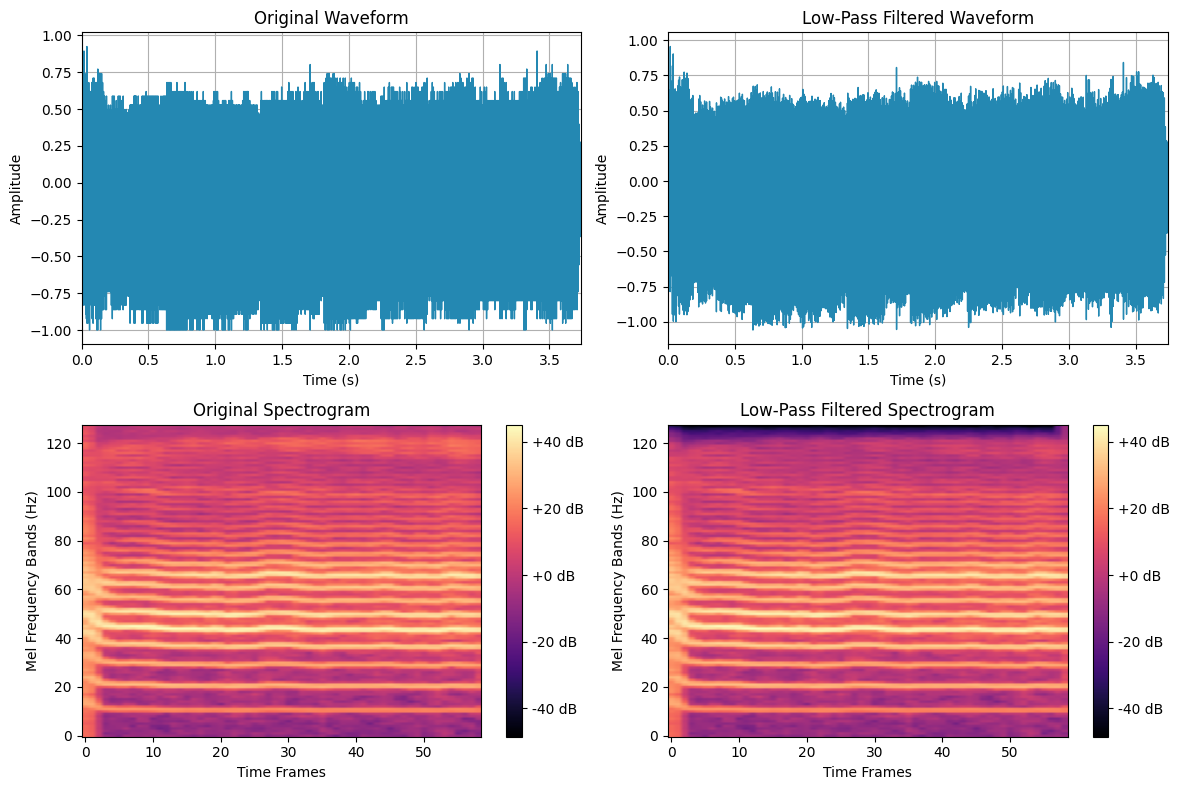

In [ ]:
def low_pass_filter(PATH):
    # Load audio and get the sample rate
    # Audio is loaded as a numpy array
    # Audi can either be: mono -> (samples, )
    # stereo -> (samples, 2)
    # or multi-channel -> (samples, channels)
    audio_np, sr = sf.read(PATH, dtype="float32")
    
    # Audio is converted into a torch tensor  
    audio = torch.tensor(audio_np)
    # Make sure that the shape is (channels, samples)
    if audio.ndim == 1:
        # Case that audio is mono
        audio = audio.unsqueeze(0) # (1, samples) i.e. (channels, samples)
    else:
        # Case that audio is stereo or multi-channel
        audio = audio.T # (channels, samples)

    mono = audio.mean(dim=0)  # Convert to mono, i.e. (samples,)

    # Creates object that represents the low pass filter augmentation
    augment = LowPassFilter(
        p=1.0,
        min_cutoff_freq=2800.0,
        max_cutoff_freq=3200.0
    )
    augmented = augment(
        samples = mono.numpy(),
        sample_rate=sr
    )
    taudio = torch.tensor(augmented).unsqueeze(0) # Convert shape back to (channels, samples)

    print("Original")
    display(Audio(audio.numpy(), rate=sr))
    print("Low pass filter")
    display(Audio(taudio.numpy(), rate=sr))

    plot_all(audio, taudio, sr, "Original", "Low-Pass Filtered")

low_pass_filter('../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav')

##### High-Pass Filter
Removes all frequences below the cut-off frequency, which is again randomly chosen betweem the min_cutoff_freq and max_cutoff_freq

Original


High pass filter


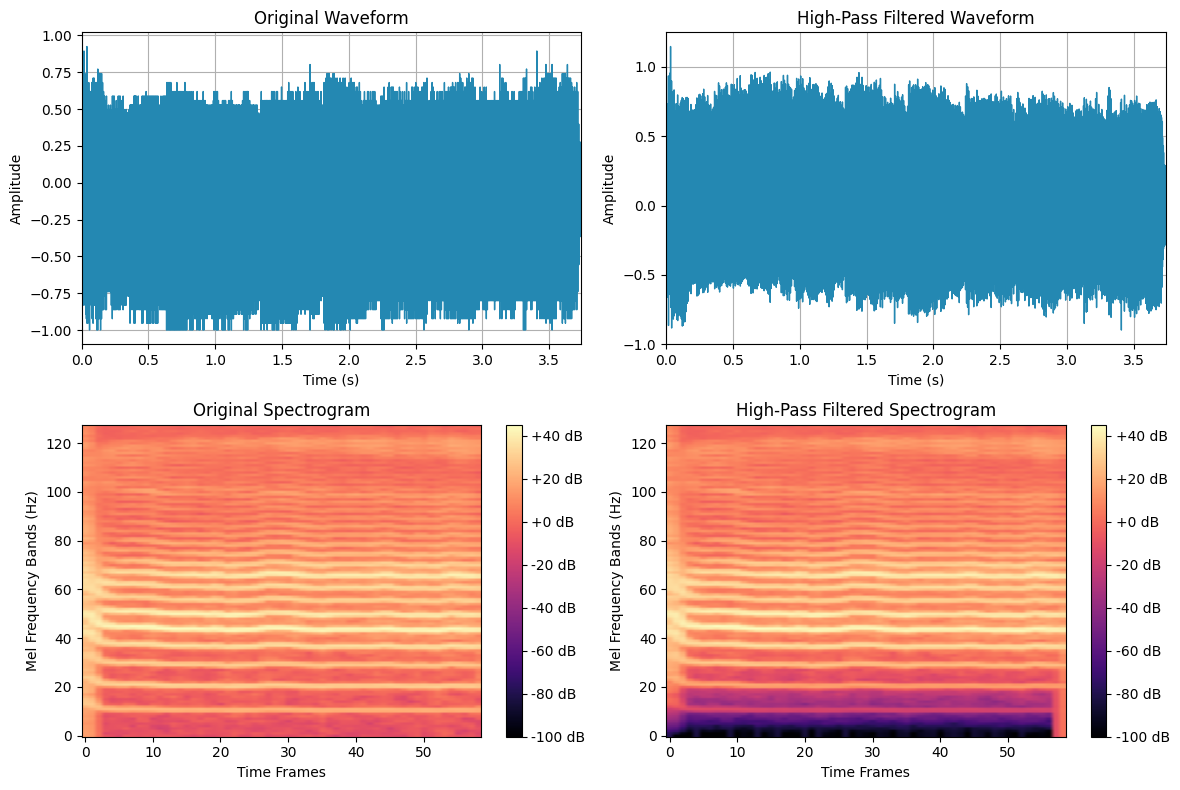

In [6]:
def high_pass_filter(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")

    audio = torch.tensor(audio_np)
    if audio.ndim == 1:
        audio = audio.unsqueeze(0) # (1, samples)
    else:
        audio = audio.T # (channels, samples)
    mono = audio.mean(dim=0)  # Conver to mono, i.e. (samples,)

    augment = HighPassFilter(
        p=1.0,
        min_cutoff_freq=200,
        max_cutoff_freq=500
    )
    augmented = augment(mono.numpy(), sample_rate=sr)
    taudio = torch.tensor(augmented).unsqueeze(0)

    print("Original")
    display(Audio(audio.numpy(), rate=sr))
    print("High pass filter")
    display(Audio(taudio.numpy(), rate=sr))

    plot_all(audio, taudio, sr, "Original", "High-Pass Filtered")

high_pass_filter('../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav')

##### Band Stop Filter
This filter blocks out a certain range of frequencies

Given a centre frequency and a bandwidth fraction, the bandwidth can be calculated with the following formula: 
$$\textnormal{bandwidth} = \textnormal{bandwidth fraction} \times \textnormal{center frequency}$$

A lower and upper bound for the blocked out range of frequencies can then be calculated using:
$$\textnormal{lower bound} = \textnormal{center frequency} - \frac{\textnormal{bandwidth}}{2}$$
$$\textnormal{upper bound} = \textnormal{center frequency} + \frac{\textnormal{bandwidth}}{2}$$

The center frequency is chosen at random between the min and max values. The bandwidth fraction is also chosen at random between the min and max values.

Original


Band stop filter


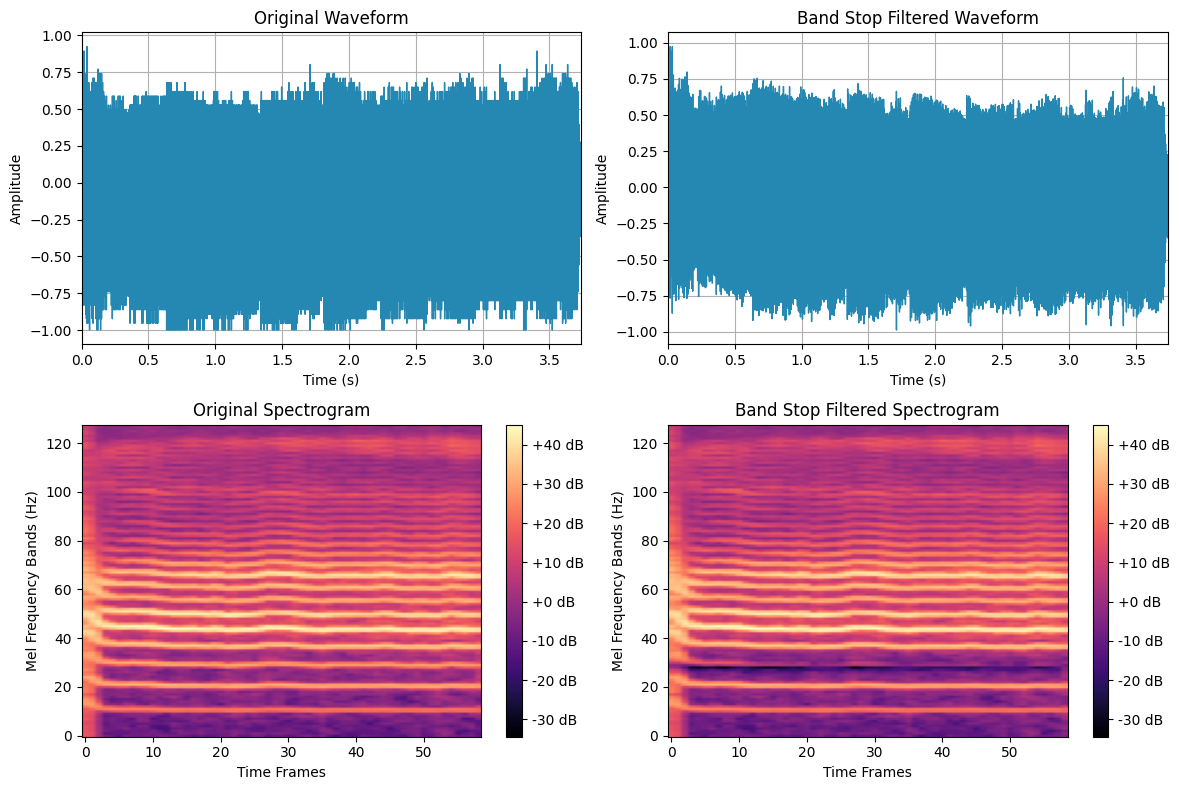

In [7]:
def add_bandstop_filter(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")

    audio = torch.tensor(audio_np)
    if audio.ndim == 1:
        audio = audio.unsqueeze(0)
    else:
        audio = audio.T
    mono = audio.mean(dim=0)
    
    augment = BandStopFilter(
        min_center_freq = 200.0,
        max_center_freq = 400.0,
        min_bandwidth_fraction = 0.2,
        max_bandwidth_fraction = 0.5,
        p=1.0,
    )
    augmented = augment(mono.numpy(), sample_rate=sr)
    taudio = torch.tensor(augmented).unsqueeze(0)
    
    print("Original")
    display(Audio(audio.numpy(), rate=sr))
    print("Band stop filter")
    display(Audio(taudio.numpy(), rate=sr))

    plot_all(audio, taudio, sr, "Original", "Band Stop Filtered")

add_bandstop_filter('../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav')

#### Pitch Shift

Original


Pitch shift


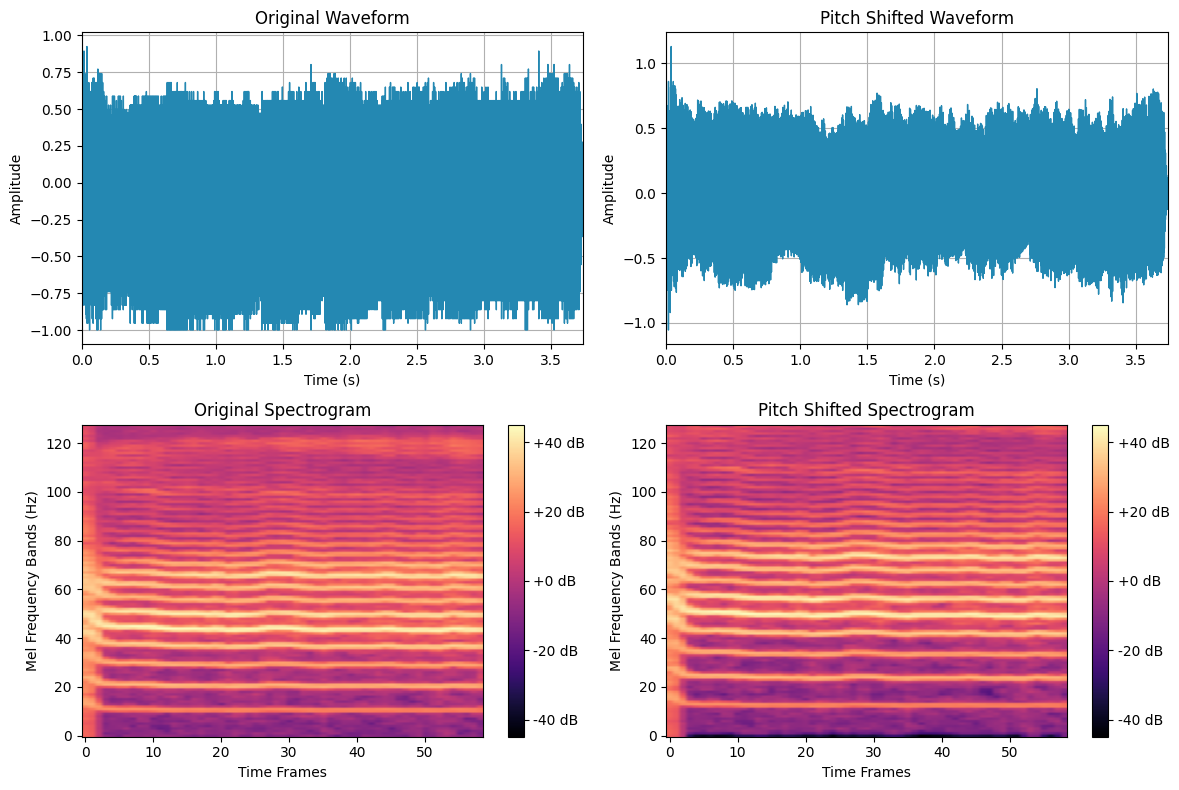

In [ ]:
def pitch_shift(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")

    audio = torch.tensor(audio_np)
    if audio.ndim == 1:
        audio = audio.unsqueeze(0)
    else:
        audio = audio.T
    mono = audio.mean(dim=0)
    
    augment = PitchShift(
        min_semitones=-3.0,
        max_semitones=3.0,
        p=1.0
    )
    augmented = augment(mono.numpy(), sample_rate=sr)
    taudio = torch.tensor(augmented).unsqueeze(0)

    print("Original")
    display(Audio(audio.numpy(), rate=sr))
    print("Pitch shift")
    display(Audio(taudio.numpy(), rate=sr))

    plot_all(audio, taudio, sr, "Original", "Pitch Shifted")

pitch_shift('../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav')

#### Gain
Audio is multiplied by a random amplitude factor, resulting in a gain between the min and max values.

Note that Jupyter notebooks will automatically noramlise the playback volume, so we cannot hear a change in volume when played through here. But the plot below clearly shows a difference in gain.

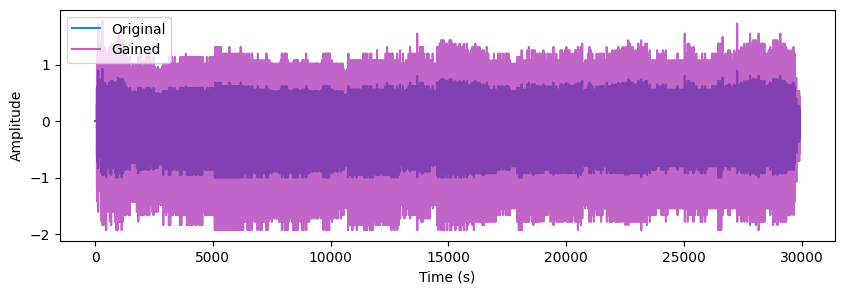

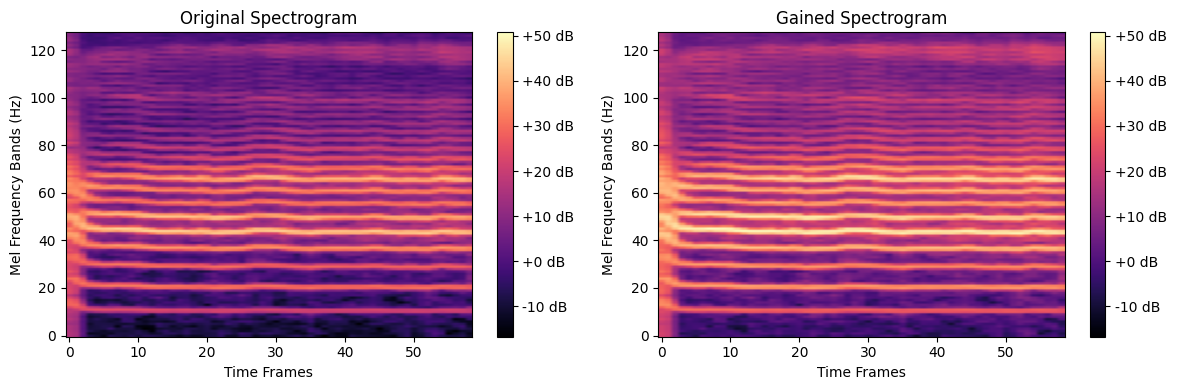

In [21]:
def add_gain(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")

    audio = torch.tensor(audio_np)
    if audio.ndim == 1:
        audio = audio.unsqueeze(0)
    else:
        audio = audio.T
    mono = audio.mean(dim = 0)
    
    augment = Gain(
        min_gain_db=-6.0,
        max_gain_db=6.0,
        p=1.0,
    )
    augmented = augment(mono.numpy(), sample_rate=sr)
    taudio = torch.tensor(augmented).unsqueeze(0)

    plt.figure(figsize=(10,3))
    plt.plot(audio[0].numpy(), label="Original", color="#2488B2")
    plt.plot(taudio[0].numpy(), label="Gained", alpha=0.7, color="#A924B2")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

    spectrogram_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    spec = spectrogram_transform(audio)
    spec_db = torchaudio.transforms.AmplitudeToDB()(spec)
    tspec = spectrogram_transform(taudio)
    tspec_db = torchaudio.transforms.AmplitudeToDB()(tspec)
    min_db = min(spec_db.min().item(), tspec_db.min().item())
    max_db = max(spec_db.max().item(), tspec_db.max().item())
    plot_spectrogram(audio, sr, "Original Spectrogram", ax=axs[0], min_db=min_db, max_db=max_db)
    plot_spectrogram(taudio, sr, "Gained Spectrogram", ax=axs[1], min_db=min_db, max_db=max_db)
    plt.tight_layout()
    plt.show()

add_gain('../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav')

#### Background

First step is to iterate through the bg-audios and normalise them so that they all have a similar volume. The target volume is still, however, randomly chosen between the min and max luf values.

In [10]:
def normalise(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")

    audio = torch.tensor(audio_np)
    if audio.ndim == 1:
        audio = audio.unsqueeze(0)
    else:
        audio = audio.T
    mono = audio.mean(dim = 0)
    
    augment = LoudnessNormalization(
        p=1.0,
        min_lufs=-45.0,
        max_lufs=-38.0
    )

    augmented = augment(
        samples = mono.numpy(), 
        sample_rate=sr
    )
    taudio = torch.tensor(augmented).unsqueeze(0)
    return taudio, sr

input_dir = "bg-audios/not-normalised-audio"
output_dir = "bg-audios/normalised-audio"

for filename in os.listdir(input_dir):
    input_path = os.path.join(input_dir, filename)
    output_path = os.path.join(output_dir, filename)

    taudio, sr = normalise(input_path)
    taudio_np = taudio.squeeze(0).numpy()
    sf.write(output_path, taudio_np.T, sr)

Original


Background added


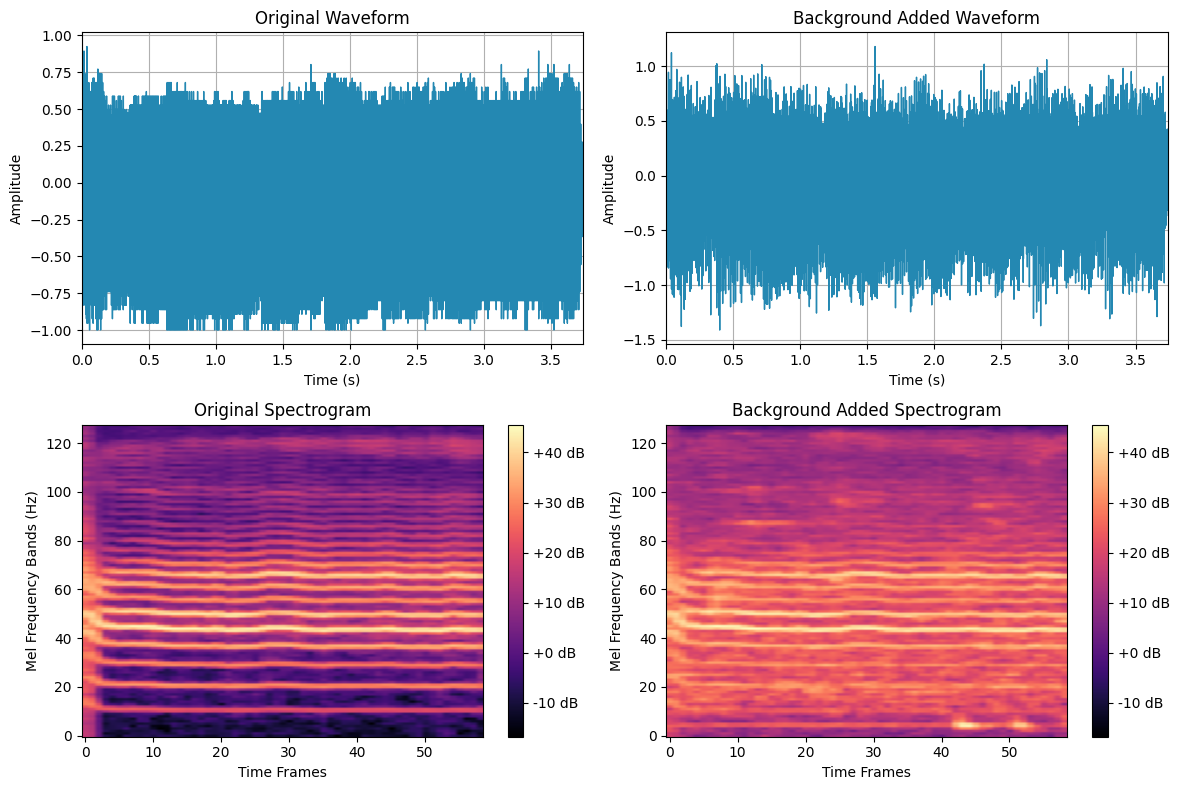

In [19]:
def add_background(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")
    audio = torch.tensor(audio_np)

    if audio.ndim == 1:
        audio = audio.unsqueeze(0)
    else:
        audio = audio.T
    mono = audio.mean(dim=0)

    augment = AddBackgroundNoise(
        sounds_path="./bg-audios/normalised-audio",
        min_snr_db=5.0,
        max_snr_db=15.0,
        p=1.0,
    )

    augmented_mono = augment(
        samples=mono.numpy(),
        sample_rate=sr
    )
    taudio = torch.tensor(augmented_mono).unsqueeze(0)

    warnings.filterwarnings("ignore", category=UserWarning)
    print("Original")
    display(Audio(audio.numpy(), rate=sr))
    print("Background added")
    display(Audio(taudio.numpy(), rate=sr))

    plot_all(audio, taudio, sr, "Original", "Background Added")

add_background("../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav")

#### Applying Impulse Responses
Impulse responses are recordings of how a certain environment responses to an impulse, which is a short, sharp sound. It is essentially able to capture the acoustic qualities of that space. By combining it with an audio, we can simulate how the audio would sound in that specific environment.

Original


Impulse response applied


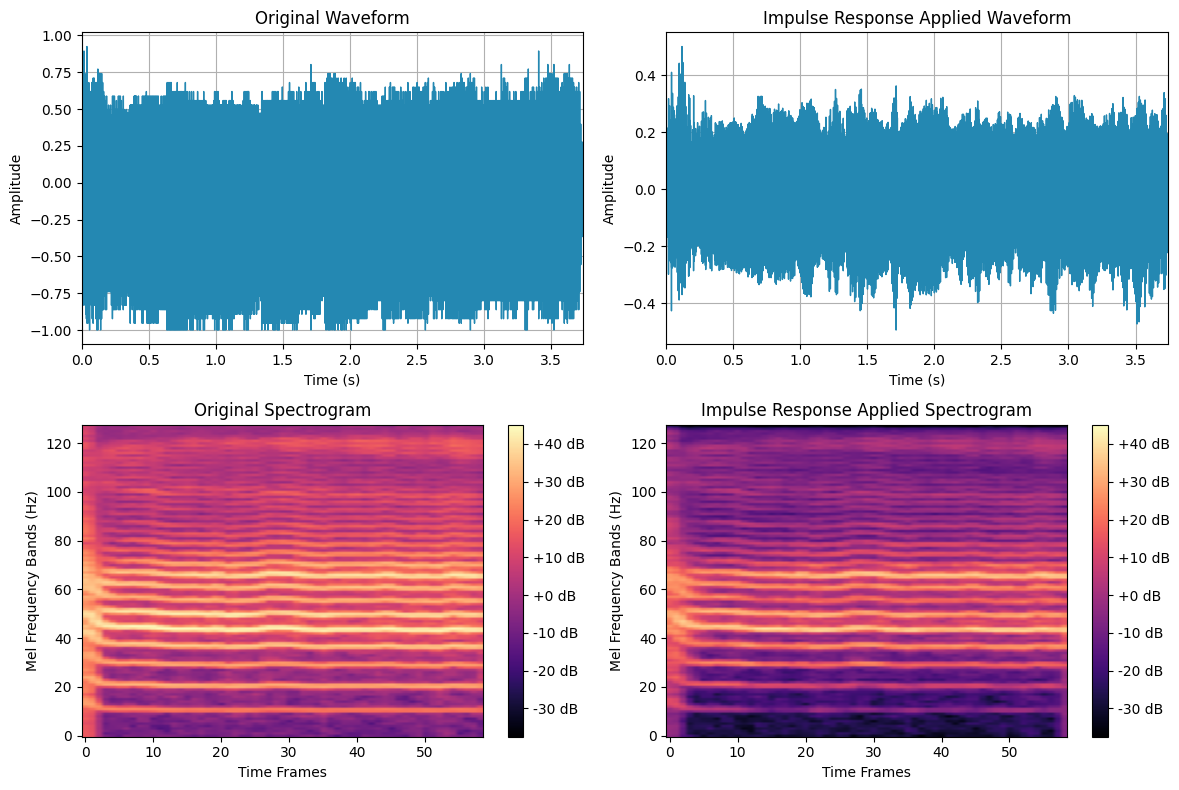

In [13]:
def apply_ir(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")
    audio = torch.tensor(audio_np)
    if audio.ndim == 1:
        audio = audio.unsqueeze(0)
    else:
        audio = audio.T
    mono = audio.mean(dim=0)
    augment = ApplyImpulseResponse(
        ir_path="./impulse-responses",
        p=1.0,
    )
    augmented_mono = augment(
        samples=mono.numpy(),
        sample_rate=sr
    )
    taudio = torch.tensor(augmented_mono).unsqueeze(0)

    print("Original")
    display(Audio(audio.numpy(), rate=sr))
    print("Impulse response applied")
    display(Audio(taudio.numpy(), rate=sr))

    plot_all(audio, taudio, sr, "Original", "Impulse Response Applied")

apply_ir("../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav")

#### Seven Band Parametric EQ
This transform allows the volume of different frequency bands to be adjusted. There are 7 frequency bands: 
- One low-shelf filter: adjusts all low frequencies below a certain cutoff
- 5 peaking filters: 5 specific mid-frequency ranges
- One high-shelf filter: adjusts all high frequencies above a certain cutoff 

For each range, there are 3 adjustable features:
- Gain: Volume change
- Q value: The width of the affected frequency range
- Center frequency: The frequency around which the range of frequencies affected is centered

A minimum and maximum gain can be set and the gain value is chosen at random for each of the 7 frequency bands. The Q value and center frequency are also randomised for each of the 7 frequency bands.

Original


Impulse response applied


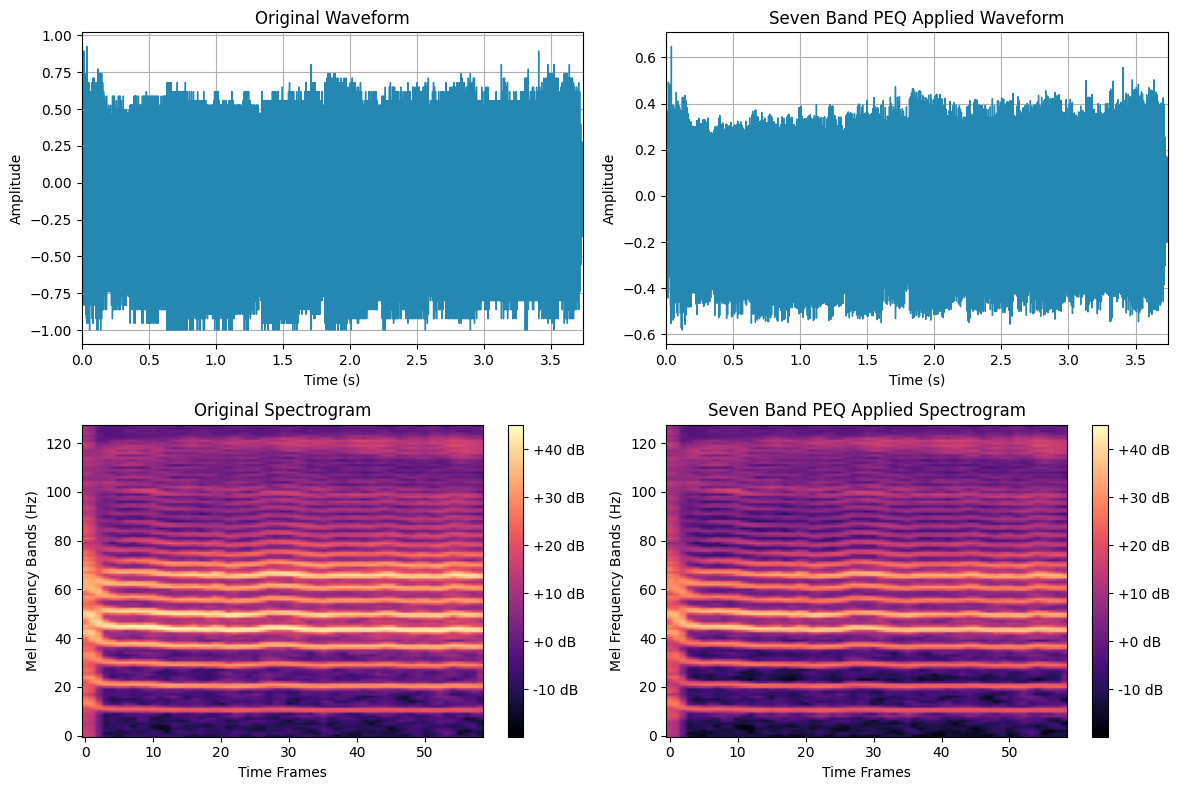

In [14]:
def apply_seven_band_peq(PATH):
    audio_np, sr = sf.read(PATH, dtype="float32")
    audio = torch.tensor(audio_np)
    if audio.ndim == 1:
        audio = audio.unsqueeze(0)
    else:
        audio = audio.T
    mono = audio.mean(dim=0)
    augment = SevenBandParametricEQ(
        min_gain_db=-12.0,
        max_gain_db=12.0,
        p=1.0,
    )
    augmented_mono = augment(
        samples=mono.numpy(),
        sample_rate=sr
    )
    taudio = torch.tensor(augmented_mono).unsqueeze(0)

    print("Original")
    display(Audio(audio.numpy(), rate=sr))
    print("Impulse response applied")
    display(Audio(taudio.numpy(), rate=sr))

    plot_all(audio, taudio, sr, "Original", "Seven Band PEQ Applied")

apply_seven_band_peq("../audio_files/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5.wav")